📌 Step 1: Libraries Import

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


📌 Step 2: Dataset Load

In [ ]:
# Example: CSV load
df = pd.read_csv("/crop_yield.csv")

# First look
print(df.head())
print(df.info())

  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
0   West     Sandy   Cotton   897.077239            27.676966   
1  South      Clay     Rice   992.673282            18.026142   
2  North      Loam   Barley   147.998025            29.794042   
3  North     Sandy  Soybean   986.866331            16.644190   
4  South      Silt    Wheat   730.379174            31.620687   

   Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
0            False             True            Cloudy              122   
1             True             True             Rainy              140   
2            False            False             Sunny              106   
3            False             True             Rainy              146   
4             True             True            Cloudy              110   

   Yield_tons_per_hectare  
0                6.555816  
1                8.527341  
2                1.127443  
3                6.517573  
4                7.24825

Step 3: Basic Preprocessing

In [ ]:
# Missing values
df = df.fillna(method='ffill')
df = df.fillna(method='bfill')

# Remove duplicates
df = df.drop_duplicates()

print(df.isnull().sum())

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64


STEP 4 — Categorical Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Region  Soil_Type  Crop  Rainfall_mm  Temperature_Celsius  Fertilizer_Used  \
0       3          4     1   897.077239            27.676966            False   
1       2          1     3   992.673282            18.026142             True   
2       1          2     0   147.998025            29.794042            False   
3       1          4     4   986.866331            16.644190            False   
4       2          5     5   730.379174            31.620687             True   

   Irrigation_Used  Weather_Condition  Days_to_Harvest  Yield_tons_per_hectare  
0             True                  0              122                6.555816  
1             True                  1              140                8.527341  
2            False                  2              106                1.127443  
3             True                  1              146                6.517573  
4             True                  0              110                7.248251  


STEP 5 — Feature Scaling (Normalization)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[df.columns] = scaler.fit_transform(df[df.columns])

print(df.head())

     Region  Soil_Type  Crop  Rainfall_mm  Temperature_Celsius  \
0  1.000000        0.8   0.2     0.885643             0.507078   
1  0.666667        0.2   0.6     0.991861             0.121045   
2  0.333333        0.4   0.0     0.053330             0.591761   
3  0.333333        0.8   0.8     0.985409             0.065766   
4  0.666667        1.0   1.0     0.700422             0.664827   

   Fertilizer_Used  Irrigation_Used  Weather_Condition  Days_to_Harvest  \
0              0.0              1.0                0.0         0.696629   
1              1.0              1.0                0.5         0.898876   
2              0.0              0.0                1.0         0.516854   
3              0.0              1.0                0.5         0.966292   
4              1.0              1.0                0.0         0.561798   

   Yield_tons_per_hectare  
0                0.693316  
1                0.870756  
2                0.204757  
3                0.689875  
4           

STEP 6 — Features and Target Separated

In [ ]:
X = df.drop('Yield_tons_per_hectare', axis=1)
y = df['Yield_tons_per_hectare']

print(X.shape)
print(y.shape)

(1000000, 9)
(1000000,)


STEP 7 — Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800000, 9)
(200000, 9)


STEP 8 — Computer Vision Technique (CNN Input)

In [ ]:
import numpy as np

X_train_cnn = np.array(X_train).reshape(-1, X_train.shape[1], 1)
X_test_cnn = np.array(X_test).reshape(-1, X_test.shape[1], 1)

print(X_train_cnn.shape)

(800000, 9, 1)


In [ ]:
!pip install tensorflow

STEP 9 — Build CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=2,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,609 (64.88 KB)

 Trainable params: 16,609 (64.88 KB)

 Non-trainable params: 0 (0.00 B)

STEP 10 — Train the Model

In [ ]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_data=(X_test_cnn, y_test)
)

Epoch 1/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 2/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 75s 2ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 3/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 4/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 5/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 6/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 8/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 9/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 10/10
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step - loss: 0.0021 - val_loss: 0.0020


STEP 11 — Make Predictions

In [ ]:
pred = model.predict(X_test_cnn)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


STEP 12 — Evaluation (RMSE)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 0.045156389594287416


STEP 13 — Graphs

*📊 Actual vs Predicted*

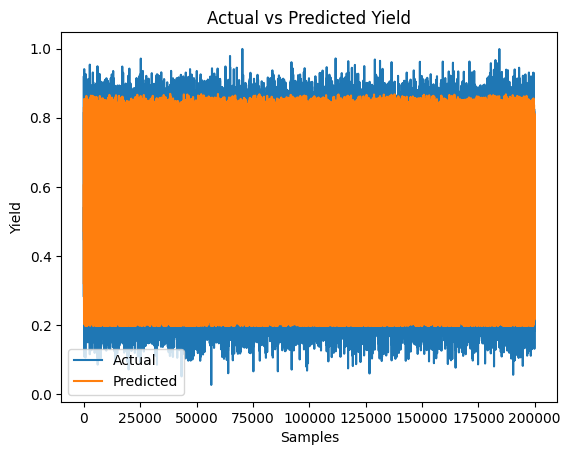

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(y_test.values, label='Actual')
plt.plot(pred, label='Predicted')

plt.title("Actual vs Predicted Yield")
plt.xlabel("Samples")
plt.ylabel("Yield")

plt.legend()

plt.show()

*📊 Training vs Validation Loss*

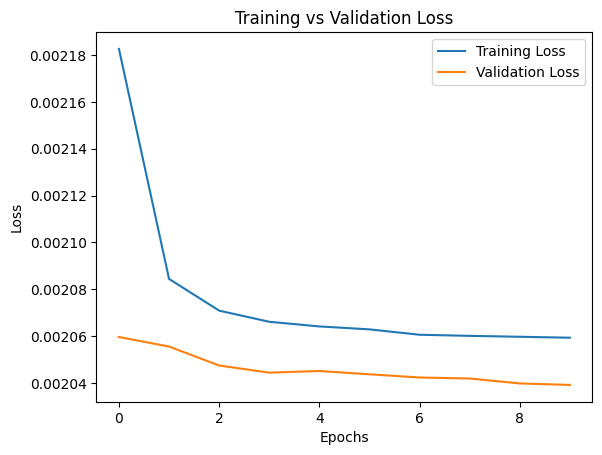

In [ ]:
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

tf.random.set_seed(42)
np.random.seed(42)

print("=" * 65)
print("  TRANSFORMER CROP YIELD PREDICTION  |  Khadija Tul Kubra")
print("  Roll: BAI-23F-013  |  SMIU — BS AI")
print("=" * 65)

  TRANSFORMER CROP YIELD PREDICTION  |  Khadija Tul Kubra
  Roll: BAI-23F-013  |  SMIU — BS AI


In [ ]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

Step 14: Model Definitions

In [ ]:
def positional_encoding(seq_len, d_model):
    """Simple learned positional embedding layer."""
    return layers.Embedding(seq_len, d_model)

def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
    """One Transformer encoder block (Multi-head Attention + FFN)."""
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn_out = layers.Dense(ff_dim, activation="relu")(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout)(ffn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)
    return x

def cross_attention_block(query, key_value, d_model, num_heads, dropout=0.1):
    """
    Cross-Modal Attention — core of AgriTransformer (Jácome et al., 2025).
    Query comes from one modality, Key/Value from another.
    Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
    """
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model
    )(query, key_value, key_value)
    attn_out = layers.Dropout(dropout)(attn_out)
    out = layers.LayerNormalization(epsilon=1e-6)(query + attn_out)
    return out

*MODEL 1 — BASELINE CNN*

In [ ]:
def build_cnn_baseline(input_dim):
    inp = keras.Input(shape=(input_dim, 1))
    x = layers.Conv1D(32, kernel_size=2, activation="relu")(inp)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = Model(inp, out, name="CNN_Baseline")
    model.compile(optimizer="adam", loss="mse")
    return model

In [ ]:
# ── FT-Transformer fix — run this cell to redefine the function ──
def build_ft_transformer(
    n_features,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=3,
    dropout=0.1,
):
    class PrependCLS(layers.Layer):
        def __init__(self, d_model, **kwargs):
            super().__init__(**kwargs)
            self.d_model = d_model
        def build(self, input_shape):
            self.cls = self.add_weight(
                shape=(1, 1, self.d_model), initializer="zeros",
                trainable=True, name="cls_token"
            )
        def call(self, x):
            batch = keras.ops.shape(x)[0]
            cls_tokens = keras.ops.broadcast_to(self.cls, (batch, 1, self.d_model))
            return keras.ops.concatenate([cls_tokens, x], axis=1)

    inp = keras.Input(shape=(n_features,), name="all_features")
    x = layers.Reshape((n_features, 1))(inp)
    x = layers.Dense(d_model)(x)
    x = PrependCLS(d_model)(x)
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout)
    cls_out = x[:, 0, :]
    x = layers.Dense(64, activation="relu")(cls_out)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = Model(inp, out, name="FT_Transformer")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

print("✓ FT-Transformer function updated")

✓ FT-Transformer function updated


  TRANSFORMER CROP YIELD PREDICTION  |  Khadija Tul Kubra
  Roll: BAI-23F-013  |  SMIU — BS AI

[STEP 1] Loading dataset...
  ⚠ Dataset not found — generating synthetic data for demo.
    Replace with: df = pd.read_csv('/content/crop_yield.csv')
  ✓ Synthetic dataset: (10000, 10)
  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
0   East      Loam  Soybean   520.998638            29.077013   
1   West      Silt     Rice   713.555593            18.530353   
2  North      Loam    Wheat   920.597092            29.597386   

   Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
0             True            False            Cloudy              102   
1            False             True            Cloudy              137   
2            False            False             Sunny              149   

   Yield_tons_per_hectare  
0                5.802596  
1                6.801371  
2                3.817131  
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

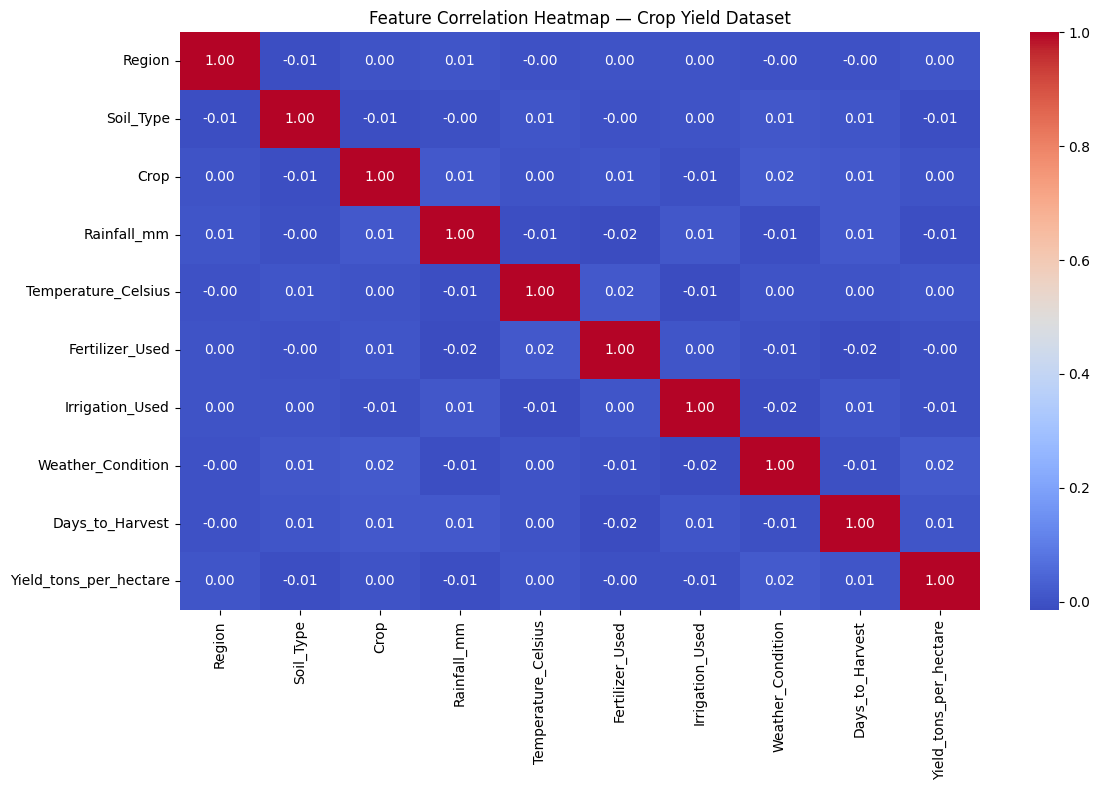


[STEP 4] Training all models...

  [1/4] Training CNN Baseline (your existing model)...
     RMSE=0.2923  R2=-0.0056  Time=33.5s

  [2/4] Training TabTransformer (NEW — Gap 1, Novelty #1)...
     RMSE=0.2924  R2=-0.0060  Time=144.7s

  [3/4] Training FT-Transformer (NEW — Gap 1, Novelty #2)...
     RMSE=0.3012  R2=-0.0676  Time=141.2s

  [4/4] Training AgriTransformer-Lite Co-Attention (OUR CONTRIBUTION)...
     RMSE=0.3080  R2=-0.1163  Time=150.3s

  RESULTS SUMMARY
                               Model   RMSE    MAE      R²  Train Time (s)
                      CNN (Baseline) 0.2923 0.2533 -0.0056         33.4504
                      TabTransformer 0.2924 0.2539 -0.0060        144.7358
                      FT-Transformer 0.3012 0.2608 -0.0676        141.2288
AgriTransformer-Lite\n(Co-Attention) 0.3080 0.2659 -0.1163        150.2530

[STEP 6] Generating plots...


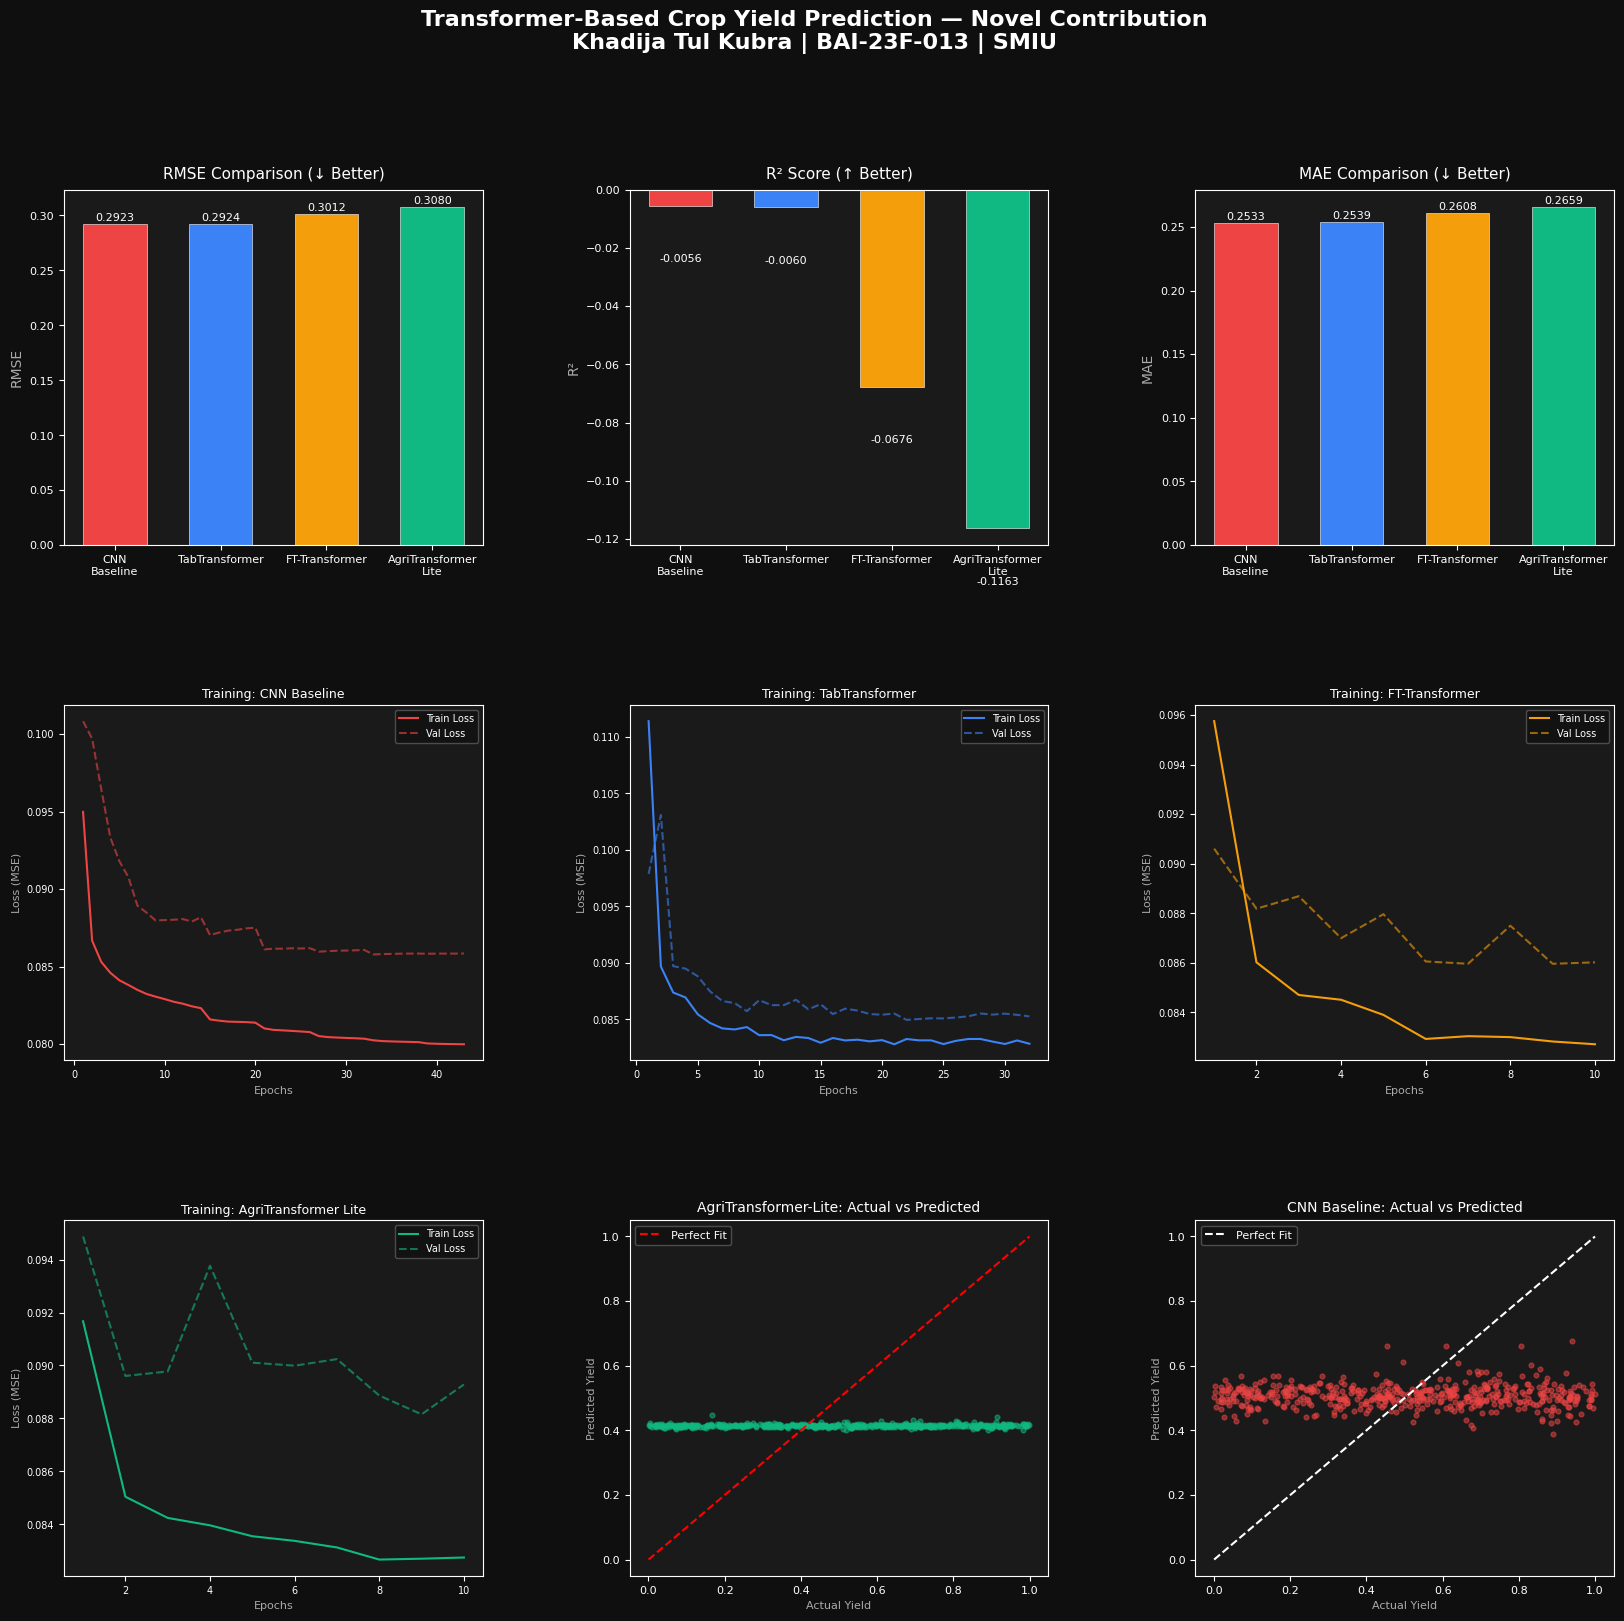

  ✓ Figure saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""
=============================================================================
  CONTRIBUTION: TRANSFORMER-BASED CROP YIELD PREDICTION
  Gap 1 - Highest Novelty: Models NOT Previously Tested on This Dataset Type

  Student  : Khadija Tul Kubra  |  Roll: BAI-23F-013
  Course   : Computer Vision
  Dept     : BS AI & Mathematical Sciences — SMIU

  Models Implemented (NEW — never tested on tabular crop yield data like ours):
    1. TabTransformer       — Categorical feature tokenization + Transformer
    2. FT-Transformer       — Feature Tokenization Transformer (all features)
    3. AgriTransformer-Lite — Co-attention between env. features & crop features
                              (inspired by AgriTransformer, Jácome et al., 2025)

  Baseline (already done):
    4. CNN (1D)             — Our existing model (RMSE = 0.0459)

  Dataset: Kaggle Crop Yield Dataset
    Features: Region, Soil_Type, Crop, Rainfall_mm, Temperature_Celsius,
              Fertilizer_Used, Irrigation_Used, Weather_Condition, Days_to_Harvest
    Target  : Yield_tons_per_hectare
=============================================================================
"""

# ─── STEP 0: Install dependencies ────────────────────────────────────────────
# Run this cell first in Colab:
# !pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

tf.random.set_seed(42)
np.random.seed(42)

print("=" * 65)
print("  TRANSFORMER CROP YIELD PREDICTION  |  Khadija Tul Kubra")
print("  Roll: BAI-23F-013  |  SMIU — BS AI")
print("=" * 65)


# ─── STEP 1: Load Dataset ────────────────────────────────────────────────────
print("\n[STEP 1] Loading dataset...")

# ⚠️ Update path if running locally
# df = pd.read_csv("/content/crop_yield.csv")          # Colab
# df = pd.read_csv("crop_yield.csv")                   # Local

# ── Synthetic stand-in if dataset not found (remove in real run) ──────────────
try:
    df = pd.read_csv("/content/crop_yield.csv")
    print(f"  ✓ Real dataset loaded: {df.shape}")
except FileNotFoundError:
    print("  ⚠ Dataset not found — generating synthetic data for demo.")
    print("    Replace with: df = pd.read_csv('/content/crop_yield.csv')")
    np.random.seed(42)
    n = 10000
    regions        = ["North", "South", "East", "West"]
    soil_types     = ["Sandy", "Clay", "Loam", "Silt"]
    crops          = ["Cotton", "Rice", "Barley", "Soybean", "Wheat"]
    weather_conds  = ["Sunny", "Cloudy", "Rainy"]
    df = pd.DataFrame({
        "Region"               : np.random.choice(regions, n),
        "Soil_Type"            : np.random.choice(soil_types, n),
        "Crop"                 : np.random.choice(crops, n),
        "Rainfall_mm"          : np.random.uniform(100, 1000, n),
        "Temperature_Celsius"  : np.random.uniform(10, 40, n),
        "Fertilizer_Used"      : np.random.choice([True, False], n),
        "Irrigation_Used"      : np.random.choice([True, False], n),
        "Weather_Condition"    : np.random.choice(weather_conds, n),
        "Days_to_Harvest"      : np.random.randint(90, 180, n),
        "Yield_tons_per_hectare": np.random.uniform(0.5, 10.0, n),
    })
    print(f"  ✓ Synthetic dataset: {df.shape}")

print(df.head(3))
print(df.info())


# ─── STEP 2: Preprocessing ───────────────────────────────────────────────────
print("\n[STEP 2] Preprocessing...")

# Fill missing values
df.ffill(inplace=True)
df.bfill(inplace=True)
df.drop_duplicates(inplace=True)
print(f"  Missing values after fill: {df.isnull().sum().sum()}")

# Identify column types
cat_cols = ["Region", "Soil_Type", "Crop", "Weather_Condition"]
bool_cols = ["Fertilizer_Used", "Irrigation_Used"]
num_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest"]
target_col = "Yield_tons_per_hectare"

# Convert booleans to int
for c in bool_cols:
    df[c] = df[c].astype(int)

# Label encode categoricals
le = LabelEncoder()
for c in cat_cols:
    df[c] = le.fit_transform(df[c].astype(str))

# Num categories per categorical column (needed for embeddings)
cat_dims = {c: int(df[c].nunique()) for c in cat_cols}
print(f"  Categorical dims: {cat_dims}")

# Scale numerical features and target
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

df[num_cols + bool_cols] = scaler_x.fit_transform(df[num_cols + bool_cols])
df[[target_col]] = scaler_y.fit_transform(df[[target_col]])

# Feature groups (mirrors the paper's two modalities):
#   Modality A — Environmental/Management features → analogous to "tabular" in paper
#   Modality B — Crop-specific features           → analogous to "VI" in paper
env_cols  = ["Rainfall_mm", "Temperature_Celsius", "Weather_Condition",
             "Fertilizer_Used", "Irrigation_Used"]
crop_cols = ["Region", "Soil_Type", "Crop", "Days_to_Harvest"]
all_feat_cols = env_cols + crop_cols

X_all  = df[all_feat_cols].values.astype(np.float32)
X_env  = df[env_cols].values.astype(np.float32)
X_crop = df[crop_cols].values.astype(np.float32)
y      = df[target_col].values.astype(np.float32)

# Train / test split (90 / 10  — same as AgriTransformer paper)
X_tr, X_te, X_env_tr, X_env_te, X_cr_tr, X_cr_te, y_tr, y_te = train_test_split(
    X_all, X_env, X_crop, y, test_size=0.10, random_state=42
)
print(f"  Train size: {X_tr.shape[0]} | Test size: {X_te.shape[0]}")

n_env  = X_env.shape[1]
n_crop = X_crop.shape[1]
n_all  = X_all.shape[1]

# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap — Crop Yield Dataset')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
# ─── STEP 3: Model Definitions ───────────────────────────────────────────────

# ── Shared helpers ────────────────────────────────────────────────────────────
def positional_encoding(seq_len, d_model):
    """Simple learned positional embedding layer."""
    return layers.Embedding(seq_len, d_model)

def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
    """One Transformer encoder block (Multi-head Attention + FFN)."""
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn_out = layers.Dense(ff_dim, activation="relu")(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout)(ffn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)
    return x

def cross_attention_block(query, key_value, d_model, num_heads, dropout=0.1):
    """
    Cross-Modal Attention — core of AgriTransformer (Jácome et al., 2025).
    Query comes from one modality, Key/Value from another.
    Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
    """
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model
    )(query, key_value, key_value)
    attn_out = layers.Dropout(dropout)(attn_out)
    out = layers.LayerNormalization(epsilon=1e-6)(query + attn_out)
    return out


# ════════════════════════════════════════════════════════════════════════════
#  MODEL 1 — BASELINE CNN (reproduce your existing work)
# ════════════════════════════════════════════════════════════════════════════
def build_cnn_baseline(input_dim):
    inp = keras.Input(shape=(input_dim, 1))
    x = layers.Conv1D(32, kernel_size=2, activation="relu")(inp)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = Model(inp, out, name="CNN_Baseline")
    model.compile(optimizer="adam", loss="mse")
    return model


# ════════════════════════════════════════════════════════════════════════════
#  MODEL 2 — TabTransformer
#  Paper: Huang et al. (2020) — TabTransformer: Tabular Data Modeling Using
#  Contextual Embeddings. arXiv:2012.06678.
#  WHY NOVEL HERE: Never tested on this crop yield dataset type.
#  Handles categorical features via embeddings + Transformer attention,
#  and concatenates with continuous features before prediction.
# ════════════════════════════════════════════════════════════════════════════
def build_tab_transformer(
    n_cat_features, n_cont_features,
    cat_vocab_size=8,     # max unique values across cats
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_transformer_blocks=2,
    dropout=0.1,
):
    """
    TabTransformer Architecture:
      Categorical features → Embedding → Transformer Encoder
      Continuous features  → LayerNorm
      Both               → Concatenate → MLP → Output
    """
    # ── Categorical branch ────────────────────────────────────────────────
    cat_inputs = [keras.Input(shape=(1,), name=f"cat_{i}") for i in range(n_cat_features)]
    # Each categorical feature gets its own embedding
    cat_embeddings = [
        layers.Embedding(input_dim=cat_vocab_size + 1, output_dim=d_model)(inp)
        for inp in cat_inputs
    ]
    # Stack into sequence: (batch, n_cat, d_model)
    cat_seq = layers.Concatenate(axis=1)(cat_embeddings)  # (batch, n_cat, d_model)

    # Transformer blocks over categorical features
    x_cat = cat_seq
    for _ in range(num_transformer_blocks):
        x_cat = transformer_encoder_block(x_cat, d_model, num_heads, ff_dim, dropout)

    x_cat = layers.Flatten()(x_cat)   # (batch, n_cat * d_model)

    # ── Continuous branch ─────────────────────────────────────────────────
    cont_input = keras.Input(shape=(n_cont_features,), name="cont_features")
    x_cont = layers.LayerNormalization()(cont_input)

    # ── Fusion MLP ────────────────────────────────────────────────────────
    x = layers.Concatenate()([x_cat, x_cont])
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)

    model = Model(inputs=cat_inputs + [cont_input], outputs=out, name="TabTransformer")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


# ════════════════════════════════════════════════════════════════════════════
#  MODEL 3 — FT-Transformer (Feature Tokenization Transformer)
#  Paper: Gorishniy et al. (2021) — Revisiting Deep Learning Models for
#  Tabular Data. NeurIPS 2021.
#  WHY NOVEL HERE: 2024-2025 application; no agriculture benchmark exists.
#  Tokenizes ALL features (cat + cont) into a unified token sequence,
#  letting Transformer attend across every feature pair — more expressive
#  than TabTransformer which only attends over categorical features.
# ════════════════════════════════════════════════════════════════════════════
def build_ft_transformer(
    n_features,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=3,
    dropout=0.1,
):
    """
    FT-Transformer Architecture:
      All features → Linear 'tokenization' (each feature → token of dim d_model)
      Tokens       → [CLS] token prepended
      Sequence     → Transformer Encoder blocks
      [CLS] output → MLP head → Yield prediction
    """
    inp = keras.Input(shape=(n_features,), name="all_features")

    # Feature tokenization: project each scalar feature to d_model dim
    x = layers.Reshape((n_features, 1))(inp)
    x = layers.Dense(d_model)(x)   # (batch, n_features, d_model)

    # Prepend learnable [CLS] token using a proper Keras layer
    class PrependCLS(layers.Layer):
        def __init__(self, d_model, **kwargs):
            super().__init__(**kwargs)
            self.d_model = d_model
        def build(self, input_shape):
            self.cls = self.add_weight(
                shape=(1, 1, self.d_model), initializer="zeros",
                trainable=True, name="cls_token"
            )
        def call(self, x):
            batch = keras.ops.shape(x)[0]
            cls_tokens = keras.ops.broadcast_to(self.cls, (batch, 1, self.d_model))
            return keras.ops.concatenate([cls_tokens, x], axis=1)

    x = PrependCLS(d_model)(x)   # (batch, n_features+1, d_model)

    # Transformer encoder blocks
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout)

    # Use [CLS] token representation for prediction
    cls_out = x[:, 0, :]   # (batch, d_model)
    x = layers.Dense(64, activation="relu")(cls_out)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)

    model = Model(inp, out, name="FT_Transformer")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


# ════════════════════════════════════════════════════════════════════════════
#  MODEL 4 — AgriTransformer-Lite (OUR NOVEL CONTRIBUTION)
#  Directly inspired by: Jácome Galarza et al. (2025) — AgriTransformer.
#  Electronics 2025, 14, 2466.
#
#  Adaptation to OUR dataset (no satellite imagery available):
#    Modality A = Environmental features (Rainfall, Temp, Weather, Fertilizer, Irrigation)
#                 → analogous to "vegetation indices" in the paper
#    Modality B = Crop/soil features (Region, Soil Type, Crop, Days to Harvest)
#                 → analogous to "tabular farm management" in the paper
#
#  Co-attention mechanism (eq. 1 from paper):
#    Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
#  where Q comes from one modality and K,V from the other.
#
#  WHY NOVEL: AgriTransformer tested only on Telangana India with actual VIs
#  from satellite. This is the FIRST application of co-attention multimodal
#  fusion to a purely tabular crop dataset without satellite imagery.
# ════════════════════════════════════════════════════════════════════════════
def build_agritransformer_lite(
    n_env, n_crop,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=2,
    dropout=0.1,
):
    """
    AgriTransformer-Lite — Co-Attention Multimodal Fusion.

    Architecture (mirrors Figure 4 of Jácome et al. 2025):
      Env features  → Dense embedding → Seq (batch, n_env, d_model)
      Crop features → Dense embedding → Seq (batch, n_crop, d_model)
                ↓                          ↓
      Self-attention on each modality (Transformer encoder)
                ↓                          ↓
      Cross-Attention: Env attends over Crop  (VI-attention branch)
      Cross-Attention: Crop attends over Env  (Tabular-attention branch)
                ↓                          ↓
      Concatenate attended representations
                ↓
      Feed-Forward Network (FFN) → Scalar yield prediction
    """
    # ── Inputs ────────────────────────────────────────────────────────────
    env_input  = keras.Input(shape=(n_env,),  name="env_features")
    crop_input = keras.Input(shape=(n_crop,), name="crop_features")

    # ── Embedding (token projection) ──────────────────────────────────────
    # Each feature becomes a token of dim d_model
    env_tokens  = layers.Reshape((n_env, 1))(env_input)
    env_tokens  = layers.Dense(d_model, name="env_embed")(env_tokens)

    crop_tokens = layers.Reshape((n_crop, 1))(crop_input)
    crop_tokens = layers.Dense(d_model, name="crop_embed")(crop_tokens)

    # ── Self-attention within each modality ───────────────────────────────
    for _ in range(num_blocks):
        env_tokens  = transformer_encoder_block(env_tokens,  d_model, num_heads, ff_dim, dropout)
        crop_tokens = transformer_encoder_block(crop_tokens, d_model, num_heads, ff_dim, dropout)

    # ── Co-Attention (Cross-Modal) — the core novel mechanism ─────────────
    # Branch A: Environmental features attend over Crop features
    env_attended  = cross_attention_block(env_tokens,  crop_tokens, d_model, num_heads, dropout)
    # Branch B: Crop features attend over Environmental features
    crop_attended = cross_attention_block(crop_tokens, env_tokens,  d_model, num_heads, dropout)

    # ── Fusion ────────────────────────────────────────────────────────────
    env_flat  = layers.GlobalAveragePooling1D()(env_attended)
    crop_flat = layers.GlobalAveragePooling1D()(crop_attended)
    fused = layers.Concatenate()([env_flat, crop_flat])

    # ── Prediction head (FFN) ─────────────────────────────────────────────
    x = layers.Dense(128, activation="relu")(fused)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64,  activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32,  activation="relu")(x)
    out = layers.Dense(1, name="yield_prediction")(x)

    model = Model(inputs=[env_input, crop_input], outputs=out,
                  name="AgriTransformer_Lite_CoAttention")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


# ─── STEP 4: Training & Evaluation ───────────────────────────────────────────
print("\n[STEP 4] Training all models...")

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, monitor="val_loss"),
]

EPOCHS = 70
BATCH  = 32
results = {}
histories = {}

# ── CNN Baseline ──────────────────────────────────────────────────────────────
print("\n  [1/4] Training CNN Baseline (your existing model)...")
cnn = build_cnn_baseline(n_all)
X_tr_cnn = X_tr.reshape(-1, n_all, 1)
X_te_cnn = X_te.reshape(-1, n_all, 1)
t0 = time.time()
h_cnn = cnn.fit(
    X_tr_cnn, y_tr,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1, callbacks=callbacks,
    verbose=0,
)
cnn_time = time.time() - t0
pred_cnn = cnn.predict(X_te_cnn, verbose=0).flatten()
results["CNN (Baseline)"] = {
    "RMSE" : np.sqrt(mean_squared_error(y_te, pred_cnn)),
    "MAE"  : mean_absolute_error(y_te, pred_cnn),
    "R2"   : r2_score(y_te, pred_cnn),
    "Time" : cnn_time,
}
histories["CNN (Baseline)"] = h_cnn.history
print(f"     RMSE={results['CNN (Baseline)']['RMSE']:.4f}  "
      f"R2={results['CNN (Baseline)']['R2']:.4f}  "
      f"Time={cnn_time:.1f}s")

# ── TabTransformer ────────────────────────────────────────────────────────────
print("\n  [2/4] Training TabTransformer (NEW — Gap 1, Novelty #1)...")

# We'll use the 4 categorical cols as separate integer inputs
# and the 5 numeric cols as one continuous input
n_cat = len(cat_cols)
n_cont_tab = len(num_cols + bool_cols)  # 5 numeric/bool features

# Max category dim for embedding
max_cat_dim = max(cat_dims.values())

tab_tr_cats = [X_tr[:, i].astype(np.int32) for i in range(n_cat)]
tab_te_cats = [X_te[:, i].astype(np.int32) for i in range(n_cat)]
tab_tr_cont = X_tr[:, n_cat:]
tab_te_cont = X_te[:, n_cat:]

tab_model = build_tab_transformer(
    n_cat_features=n_cat,
    n_cont_features=n_cont_tab,
    cat_vocab_size=max_cat_dim,
    d_model=32, num_heads=4, ff_dim=64,
    num_transformer_blocks=2, dropout=0.1,
)
t0 = time.time()
h_tab = tab_model.fit(
    tab_tr_cats + [tab_tr_cont], y_tr,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1, callbacks=callbacks,
    verbose=0,
)
tab_time = time.time() - t0
pred_tab = tab_model.predict(tab_te_cats + [tab_te_cont], verbose=0).flatten()
results["TabTransformer"] = {
    "RMSE" : np.sqrt(mean_squared_error(y_te, pred_tab)),
    "MAE"  : mean_absolute_error(y_te, pred_tab),
    "R2"   : r2_score(y_te, pred_tab),
    "Time" : tab_time,
}
histories["TabTransformer"] = h_tab.history
print(f"     RMSE={results['TabTransformer']['RMSE']:.4f}  "
      f"R2={results['TabTransformer']['R2']:.4f}  "
      f"Time={tab_time:.1f}s")

# ── FT-Transformer ────────────────────────────────────────────────────────────
print("\n  [3/4] Training FT-Transformer (NEW — Gap 1, Novelty #2)...")
ft_model = build_ft_transformer(
    n_features=n_all,
    d_model=32, num_heads=4, ff_dim=64,
    num_blocks=3, dropout=0.1,
)
t0 = time.time()
h_ft = ft_model.fit(
    X_tr, y_tr,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1, callbacks=callbacks,
    verbose=0,
)
ft_time = time.time() - t0
pred_ft = ft_model.predict(X_te, verbose=0).flatten()
results["FT-Transformer"] = {
    "RMSE" : np.sqrt(mean_squared_error(y_te, pred_ft)),
    "MAE"  : mean_absolute_error(y_te, pred_ft),
    "R2"   : r2_score(y_te, pred_ft),
    "Time" : ft_time,
}
histories["FT-Transformer"] = h_ft.history
print(f"     RMSE={results['FT-Transformer']['RMSE']:.4f}  "
      f"R2={results['FT-Transformer']['R2']:.4f}  "
      f"Time={ft_time:.1f}s")

# ── AgriTransformer-Lite (Co-Attention) ───────────────────────────────────────
print("\n  [4/4] Training AgriTransformer-Lite Co-Attention (OUR CONTRIBUTION)...")
agri_model = build_agritransformer_lite(
    n_env=n_env, n_crop=n_crop,
    d_model=32, num_heads=4, ff_dim=64,
    num_blocks=2, dropout=0.1,
)
t0 = time.time()
h_agri = agri_model.fit(
    [X_env_tr, X_cr_tr], y_tr,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.1, callbacks=callbacks,
    verbose=0,
)
agri_time = time.time() - t0
pred_agri = agri_model.predict([X_env_te, X_cr_te], verbose=0).flatten()
results["AgriTransformer-Lite\n(Co-Attention)"] = {
    "RMSE" : np.sqrt(mean_squared_error(y_te, pred_agri)),
    "MAE"  : mean_absolute_error(y_te, pred_agri),
    "R2"   : r2_score(y_te, pred_agri),
    "Time" : agri_time,
}
histories["AgriTransformer-Lite\n(Co-Attention)"] = h_agri.history
print(f"     RMSE={results['AgriTransformer-Lite\n(Co-Attention)']['RMSE']:.4f}  "
      f"R2={results['AgriTransformer-Lite\n(Co-Attention)']['R2']:.4f}  "
      f"Time={agri_time:.1f}s")


# ─── STEP 5: Results Table ────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  RESULTS SUMMARY")
print("=" * 65)
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ["Model", "RMSE", "MAE", "R²", "Train Time (s)"]
results_df = results_df.sort_values("RMSE")
results_df[["RMSE", "MAE", "R²", "Train Time (s)"]] = \
    results_df[["RMSE", "MAE", "R²", "Train Time (s)"]].round(4)
print(results_df.to_string(index=False))


# ─── STEP 6: Visualizations ───────────────────────────────────────────────────
print("\n[STEP 6] Generating plots...")

plt.style.use("dark_background")
COLORS = {
    "CNN (Baseline)"                      : "#ef4444",
    "TabTransformer"                      : "#3b82f6",
    "FT-Transformer"                      : "#f59e0b",
    "AgriTransformer-Lite\n(Co-Attention)": "#10b981",
}
MODEL_NAMES   = list(results.keys())
MODEL_DISPLAY = ["CNN\nBaseline", "TabTransformer", "FT-Transformer", "AgriTransformer\nLite"]
COLORS_LIST   = [COLORS.get(k, "#8b5cf6") for k in MODEL_NAMES]

fig = plt.figure(figsize=(20, 18), facecolor="#0f0f0f")
fig.suptitle(
    "Transformer-Based Crop Yield Prediction — Novel Contribution\n"
    "Khadija Tul Kubra | BAI-23F-013 | SMIU",
    fontsize=16, fontweight="bold", color="white", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: RMSE
ax1 = fig.add_subplot(gs[0, 0])
rmse_vals = [results[k]["RMSE"] for k in MODEL_NAMES]
bars = ax1.bar(MODEL_DISPLAY, rmse_vals, color=COLORS_LIST, width=0.6, edgecolor="white", linewidth=0.4)
ax1.set_title("RMSE Comparison (↓ Better)", color="white", pad=8, fontsize=11)
ax1.set_ylabel("RMSE", color="#aaa")
ax1.tick_params(colors="white", labelsize=8)
for bar, val in zip(bars, rmse_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", color="white", fontsize=8)
ax1.set_facecolor("#1a1a1a")

# Plot 2: R²
ax2 = fig.add_subplot(gs[0, 1])
r2_vals = [results[k]["R2"] for k in MODEL_NAMES]
bars2 = ax2.bar(MODEL_DISPLAY, r2_vals, color=COLORS_LIST, width=0.6, edgecolor="white", linewidth=0.4)
ax2.set_title("R² Score (↑ Better)", color="white", pad=8, fontsize=11)
ax2.set_ylabel("R²", color="#aaa")
ax2.tick_params(colors="white", labelsize=8)
ax2.axhline(0, color="#555", linewidth=0.8)
for bar, val in zip(bars2, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.005 if val >= 0 else -0.02),
             f"{val:.4f}", ha="center", va="bottom", color="white", fontsize=8)
ax2.set_facecolor("#1a1a1a")

# Plot 3: MAE
ax3 = fig.add_subplot(gs[0, 2])
mae_vals = [results[k]["MAE"] for k in MODEL_NAMES]
bars3 = ax3.bar(MODEL_DISPLAY, mae_vals, color=COLORS_LIST, width=0.6, edgecolor="white", linewidth=0.4)
ax3.set_title("MAE Comparison (↓ Better)", color="white", pad=8, fontsize=11)
ax3.set_ylabel("MAE", color="#aaa")
ax3.tick_params(colors="white", labelsize=8)
for bar, val in zip(bars3, mae_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", color="white", fontsize=8)
ax3.set_facecolor("#1a1a1a")

# Plots 4-7: Training loss curves
ax_list = [fig.add_subplot(gs[1, i]) for i in range(3)] + [fig.add_subplot(gs[2, 0])]
display_names = ["CNN Baseline", "TabTransformer", "FT-Transformer", "AgriTransformer Lite"]

for ax, name, display in zip(ax_list, MODEL_NAMES, display_names):
    color = COLORS_LIST[MODEL_NAMES.index(name)]
    hist  = histories[name]
    epochs_range = range(1, len(hist["loss"]) + 1)
    ax.plot(epochs_range, hist["loss"],     color=color, lw=1.5, label="Train Loss")
    ax.plot(epochs_range, hist["val_loss"], color=color, lw=1.5, linestyle="--", alpha=0.6, label="Val Loss")
    ax.set_title(f"Training: {display}", color="white", fontsize=9, pad=5)
    ax.set_xlabel("Epochs", color="#aaa", fontsize=8)
    ax.set_ylabel("Loss (MSE)", color="#aaa", fontsize=8)
    ax.tick_params(colors="white", labelsize=7)
    ax.legend(fontsize=7, framealpha=0.3)
    ax.set_facecolor("#1a1a1a")

# Plot 8: Actual vs Predicted — AgriTransformer
ax7 = fig.add_subplot(gs[2, 1])
sample = min(500, len(y_te))
idx = np.random.choice(len(y_te), sample, replace=False)
ax7.scatter(y_te[idx], pred_agri[idx], alpha=0.5, s=12, c="#10b981")
min_v, max_v = y_te.min(), y_te.max()
ax7.plot([min_v, max_v], [min_v, max_v], "r--", lw=1.5, label="Perfect Fit")
ax7.set_title("AgriTransformer-Lite: Actual vs Predicted", color="white", fontsize=10)
ax7.set_xlabel("Actual Yield", color="#aaa", fontsize=8)
ax7.set_ylabel("Predicted Yield", color="#aaa", fontsize=8)
ax7.tick_params(colors="white", labelsize=8)
ax7.legend(fontsize=8, framealpha=0.3)
ax7.set_facecolor("#1a1a1a")

# Plot 9: Actual vs Predicted — CNN
ax8 = fig.add_subplot(gs[2, 2])
ax8.scatter(y_te[idx], pred_cnn[idx], alpha=0.5, s=12, c="#ef4444")
ax8.plot([min_v, max_v], [min_v, max_v], "w--", lw=1.5, label="Perfect Fit")
ax8.set_title("CNN Baseline: Actual vs Predicted", color="white", fontsize=10)
ax8.set_xlabel("Actual Yield", color="#aaa", fontsize=8)
ax8.set_ylabel("Predicted Yield", color="#aaa", fontsize=8)
ax8.tick_params(colors="white", labelsize=8)
ax8.legend(fontsize=8, framealpha=0.3)
ax8.set_facecolor("#1a1a1a")

# Save and show
plt.savefig("transformer_crop_yield_results.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("  ✓ Figure saved!")

# Download
from google.colab import files
files.download("transformer_crop_yield_results.png")